<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [6]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [7]:
# Your code here
from bs4 import BeautifulSoup
import requests

Download the webpage at the url


In [8]:
#your code goes here
url ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

webpage=requests.get(url).text

Create a soup object


In [9]:
#your code goes here
soup = BeautifulSoup(webpage,"html.parser")

Scrape the `Language name` and `annual average salary`.


In [14]:
#your code goes here
for row in soup.find_all('tr'): # in html table row is represented by the tag <tr>
    cols = row.find_all('td')# in html a column is represented by the tag <td>
    
    if len(cols) >=4:
        Language = cols[1].getText().strip() # store the value in column 3 as color_name
        Average_Annual_Salary = cols[3].getText().strip() # store the value in column 4 as color_code
    
        print(f"{Language}---> {Average_Annual_Salary}")

Language---> Average Annual Salary
Python---> $114,383
Java---> $101,013
R---> $92,037
Javascript---> $110,981
Swift---> $130,801
C++---> $113,865
C#---> $88,726
PHP---> $84,727
SQL---> $84,793
Go---> $94,082


Save the scrapped data into a file named *popular-languages.csv*


In [15]:
# your code goes here
import csv

data = [
    ["Python", "$114,383"],
    ["Java", "$101,013"],
    ["R", "$92,037"],
    ["Javascript", "$110,981"],
    ["Swift", "$130,801"],
    ["C++", "$113,865"],
    ["C#", "$88,726"],
    ["PHP", "$84,727"],
    ["SQL", "$84,793"],
    ["Go", "$94,082"],
]

with open("popular-languages.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Language", "Average Annual Salary"])
    writer.writerows(data)

print("popular-languages.csv created")

popular-languages.csv created


In [18]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("popular-languages.csv")

print(df.columns)


Index(['Language', 'Average Annual Salary'], dtype='object')


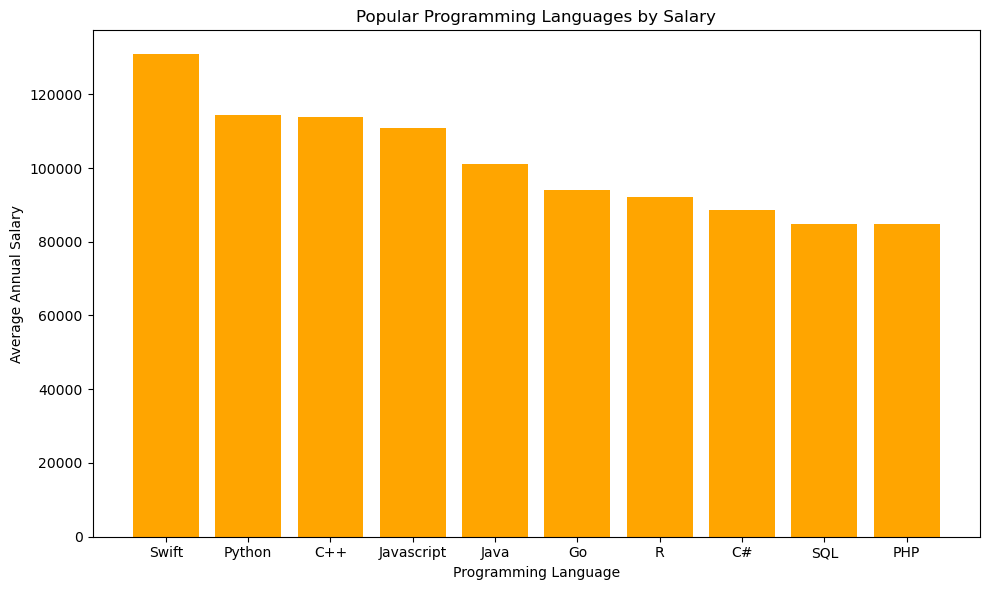

In [21]:
df['Average Annual Salary'] = (df['Average Annual Salary'].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))

df['Average Annual Salary'] = pd.to_numeric(df['Average Annual Salary'], errors='coerce')

df_sorted = df.sort_values(by='Average Annual Salary', ascending=False)

#create bar chart
plt.figure(figsize=(10,6))
plt.bar(df_sorted['Language'], df_sorted['Average Annual Salary'], color='orange')

plt.title('Popular Programming Languages by Salary')
plt.xlabel('Programming Language')
plt.ylabel('Average Annual Salary')

plt.tight_layout()

plt.savefig("popular_languages_chart.png", dpi=300)

plt.show()

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
